In [19]:
import pandas as pd

# Load the CSV
df_loaded = pd.read_csv("Spin_echo(T2)_results/T2_Echo_Q2_20250826T084437.csv")
qubit_label = 2 # Change this to the appropriate qubit label if needed
# Extract the desired columns
delay_us = df_loaded["Delay_us"].to_numpy()
mag      = df_loaded["Magnitude_linear"].to_numpy()
phase    = df_loaded["Phase_rad"].to_numpy()

print(delay_us.shape, mag.shape, phase.shape)


(201,) (201,) (201,)


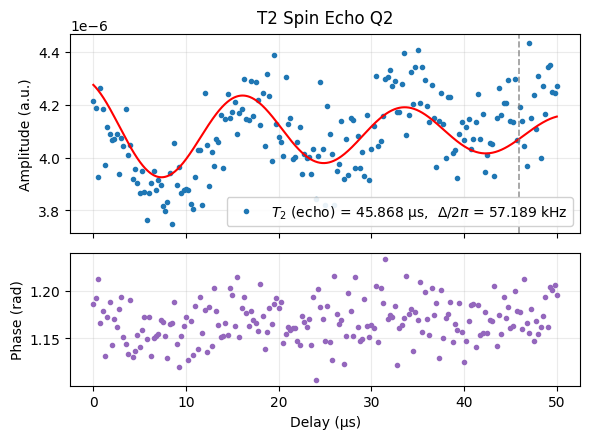

{'T2_us': 45.868463773584295, 'A': 1.9911432472466607e-07, 'C': 4.0944734323514e-06, 'detuning_delta_over_2pi_kHz': 57.18907526306744, 'detuning_delta_rad_per_us': 0.35932955742409284, 'phi_rad': 0.43501738801090617}


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from numpy.fft import rfftfreq, rfft

# expects arrays: delay_us, mag, phase
x   = np.asarray(delay_us, float)          # delay between pulses (TE) in μs
y   = np.asarray(mag, float)               # magnitude (a.u.)
phi = np.asarray(phase, float)             # phase (rad)

# --- clean and sort ---
m = np.isfinite(x) & np.isfinite(y) & np.isfinite(phi)
x, y, phi = x[m], y[m], phi[m]
idx = np.argsort(x)
x, y, phi = x[idx], y[idx], phi[idx]
if x.size < 5:
    raise RuntimeError("Not enough valid points to fit.")

# ---------------------------
# Spin-echo model with ripple
# M(TE) = A * exp(-TE/T2) * cos(2π f * TE + φ0) + C
# (TE in μs, f in MHz)
# ---------------------------
def model_echo(delay_us, A, T2_us, f_MHz, phi0, C):
    T2_us     = np.maximum(T2_us, 1e-9)
    delay_us  = np.maximum(delay_us, 0.0)
    osc       = np.cos(2*np.pi * f_MHz * delay_us + phi0)
    return A * np.exp(-delay_us / T2_us) * osc + C

# --- initial guesses ---
C0  = float(np.nanmedian(y))
y_d = y - C0

# FFT-based frequency guess (in MHz since x is μs)
try:
    xu = np.linspace(x.min(), x.max(), min(4096, max(256, 4*len(x))))
    yu = np.interp(xu, x, y_d)
    Yf = np.abs(rfft(yu - np.mean(yu)))
    freqs = rfftfreq(len(xu), d=(xu[1]-xu[0]))  # MHz (since x in μs)
    k = np.argmax(Yf[1:]) + 1 if len(Yf) > 1 else 0
    f_guess = float(freqs[k]) if k > 0 else 0.0
    if not np.isfinite(f_guess) or f_guess < 0:
        f_guess = 0.0
except Exception:
    f_guess = 0.0

A0   = 0.5 * (np.nanmax(y_d) - np.nanmin(y_d))
T20  = max(np.percentile(x, 60), 1e-3)
phi0 = 0.0

p0 = [A0 if np.isfinite(A0) else 1.0, T20, f_guess, phi0, C0]

# bounds
try:
    f_nyq = 0.5 / (xu[1] - xu[0])  # MHz
except Exception:
    f_nyq = 10.0  # MHz fallback

bounds = ([-np.inf, 1e-6, 0.0, -4*np.pi, -np.inf],
          [ np.inf,  np.inf,  f_nyq,  4*np.pi,  np.inf])

# --- fit ---
popt, pcov = curve_fit(model_echo, x, y, p0=p0, bounds=bounds, maxfev=50000)
A_fit, T2_fit_us, f_fit_MHz, phi_fit, C_fit = popt

# Convert to detuning labels
delta_Hz = f_fit_MHz * 1e6                 # Δ/2π in Hz (same as f in Hz)
delta_kHz = f_fit_MHz * 1e3                # Δ/2π in kHz (nice for display)
delta_rad_per_us = 2*np.pi * f_fit_MHz     # Δ in rad/μs

# --- smooth curve for display ---
xf = np.linspace(x.min(), x.max(), 1200)
yf = model_echo(xf, *popt)

# --- plot (same format) ---
fig, axs = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True,
                        gridspec_kw={'height_ratios': [1.5, 1.0]})

# magnitude + fit
axs[0].plot(x, y, 'o', ms=3, label="|IQ|")
# Update the label to use Δ instead of f
axs[0].plot(
    xf, yf, '-r', lw=1.5,
    label=r"fit: $A e^{-{\rm Delay}/T_2}\cos(\Delta\,{\rm Delay}+\phi)+C$"
)

# only draw T2 vertical line if it's inside the measured range
if x.min() <= T2_fit_us <= x.max():
    axs[0].axvline(T2_fit_us, linestyle='--', linewidth=1.2, alpha=0.8, color='grey')

axs[0].set_ylabel("Amplitude (a.u.)")
# Legend now shows detuning; report Δ as kHz (linear frequency) for intuition
axs[0].legend(
    [rf"$T_2$ (echo) = {T2_fit_us:.3f} μs,  $\Delta/2\pi$ = {delta_kHz:.3f} kHz"],
    loc="lower right", framealpha=0.9
)
axs[0].grid(True, alpha=0.25)
axs[0].set_title(f"T2 Spin Echo Q{qubit_label}", fontsize=12, pad=8)

# phase subplot
axs[1].plot(x, np.unwrap(phi), 'o', ms=3, color='tab:purple')
axs[1].set_xlabel("Delay (μs)")
axs[1].set_ylabel("Phase (rad)")
axs[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(f"Spin_echo(T2)_results/T2_echo_Q{qubit_label}.png", dpi=600)
plt.show()

print({
    "T2_us": float(T2_fit_us),
    "A": float(A_fit),
    "C": float(C_fit),
    "detuning_delta_over_2pi_kHz": float(delta_kHz),
    "detuning_delta_rad_per_us": float(delta_rad_per_us),
    "phi_rad": float(phi_fit)
})

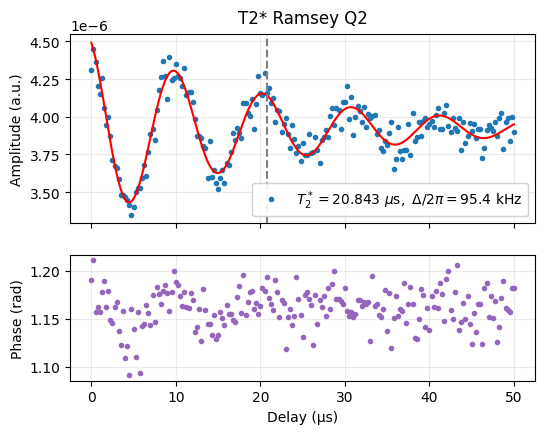

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========= User inputs =========
df     = pd.read_csv("Ramsey(T2)_results/T2_Ramsey_Q2_20250826T083216.csv")  # <-- update to your file
qubit_label  = "Q2"                                                         # label for title
# =================================

# ---------- Model (same as before) ----------
def T2_ramsey_model(t_us, A, T2star_us, fdet_MHz, phi, C):
    return A * np.exp(-t_us / T2star_us) * np.cos(2.0*np.pi * fdet_MHz * t_us + phi) + C

# ---------- Load CSV ----------

# Pull arrays (as saved in your previous code)
x_us   = np.asarray(df["Delay_us"], float)
I      = np.asarray(df["I"], float)
Q      = np.asarray(df["Q"], float)
mag    = np.asarray(df["Magnitude_linear"], float)
phase  = np.asarray(df["Phase_rad"], float)

# Extract fit parameters (constant across rows — take the first)
A_fit          = float(df["A_fit"].iloc[0])
T2star_fit_us  = float(df["T2star_fit_us"].iloc[0])
fdet_fit_MHz   = float(df["fdet_fit_MHz"].iloc[0])
phi_fit        = float(df["phi_fit"].iloc[0])
C_fit          = float(df["C_fit"].iloc[0])

# Compute a smooth fit curve for plotting
xf = np.linspace(x_us.min(), x_us.max(), 1200)
y_fit = T2_ramsey_model(xf, A_fit, T2star_fit_us, fdet_fit_MHz, phi_fit, C_fit)

# Detuning in kHz (Delta/2π)
detuning_kHz = 1e3 * fdet_fit_MHz

# ---------- Plot ----------
fig, axs = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True,
                        gridspec_kw={'height_ratios': [1.5, 1.0]})

# Top: magnitude with fit
axs[0].plot(x_us, mag, 'o', ms=3, label="|IQ| (a.u.)")
axs[0].plot(xf, y_fit, '-r', lw=1.5, label="fit on |IQ|")
axs[0].axvline(T2star_fit_us, color="grey", linestyle="--", linewidth=1.5)
axs[0].set_ylabel("Amplitude (a.u.)")
axs[0].grid(True, alpha=0.25)

# Single legend line including T2* AND detuning (Delta/2pi) in kHz
axs[0].legend(
    [rf"$T_2^*={T2star_fit_us:.3f}\ \mu\mathrm{{s}},\ \Delta/2\pi={detuning_kHz:.1f}\ \mathrm{{kHz}}$"],
    loc="lower right", framealpha=0.9
)

axs[0].set_title(f"T2* Ramsey {qubit_label}", fontsize=12, pad=8)

# Bottom: unwrapped phase
phase_unw = np.unwrap(phase)
axs[1].plot(x_us, phase_unw, 'o', ms=3, color="tab:purple")
axs[1].set_xlabel("Delay (μs)")
axs[1].set_ylabel("Phase (rad)")
axs[1].grid(True, alpha=0.25)

# ---------- Save & show ----------
plt.savefig("Ramsey(T2)_results/Q2_with_detuning.png", dpi=600)
plt.show()
